# Italian Air Quality — EDA Overview

Quick exploratory analysis of an Italian air quality dataset containing hourly sensor readings and ground-truth pollutant concentrations. The goal is to give everyone a feel for what this dataset looks like, what's in it, and whether it's worth using for our project.

## Setup

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

## Loading & First Look

Basic shape of the dataset — how many rows, columns, and missing values we're dealing with.

In [85]:
air_quality = pd.read_csv('datasets/air_quality_italy.csv')
print(f"First row:\n{air_quality.head(1)}")
print(f"Number of rows: {len(air_quality)}")
print(f"Number of columns: {air_quality.columns.size}")
print(f"Number of nan values:\n{air_quality.isna().sum()}")

First row:
         Date  CO_GT  PT08_S1_CO  C6H6_GT  PT08_S2_NMHC  NOx_GT  PT08_S3_NOx  \
0  2004-03-10    2.6        1360     11.9          1046     166         1056   

   NO2_GT  PT08_S4_NO2  PT08_S5_O3     T    RH      AH  Hour high_NO2  
0     113         1692        1268  13.6  48.9  0.7578    18     High  
Number of rows: 9357
Number of columns: 15
Number of nan values:
Date            0
CO_GT           0
PT08_S1_CO      0
C6H6_GT         0
PT08_S2_NMHC    0
NOx_GT          0
PT08_S3_NOx     0
NO2_GT          0
PT08_S4_NO2     0
PT08_S5_O3      0
T               0
RH              0
AH              0
Hour            0
high_NO2        0
dtype: int64


### Variable Descriptions

| Name | Description |
|---|---|
| `Date` | Date of the hourly observation. |
| `CO_GT` | Reference/ground-truth concentration of carbon monoxide (CO), usually measured in mg/m³. |
| `PT08_S1_C` | Sensor response from PT08.S1, a metal-oxide sensor mainly associated with CO detection. |
| `C6H6_GT` | Reference/ground-truth concentration of benzene (C6H6), usually measured in µg/m³. |
| `PT08_S2_N` | Sensor response from PT08.S2, mainly associated with non-methane hydrocarbons (NMHC). |
| `NOx_GT` | Reference/ground-truth concentration of nitrogen oxides (NOx). |
| `PT08_S3_N` | Sensor response from PT08.S3, mainly associated with NOx detection. |
| `NO2_GT` | Reference/ground-truth concentration of nitrogen dioxide (NO2). |
| `PT08_S4_N` | Sensor response from PT08.S4, mainly associated with NO2 detection. |
| `PT08_S5_O` | Sensor response from PT08.S5, commonly associated with ozone/oxidizing gases. |
| `T` | Temperature, usually measured in degrees Celsius. |
| `RH` | Relative humidity, measured as a percentage. |
| `AH` | Absolute humidity. |
| `Hour` | Hour of the day, ranging from 0 to 23. |
| `high_NO2` | Derived categorical variable indicating whether NO2 level is classified as `High` or `Low`. |

### Summary Statistics

In [86]:
air_quality.describe()

,CO_GT,PT08_S1_CO,C6H6_GT,PT08_S2_NMHC,NOx_GT,PT08_S3_NOx,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH,Hour
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,0.126729,1098.392433,1.865683,937.973923,235.178903,834.339959,112.373303,1456.528054,1020.562894,18.297574,49.248509,1.024352,11.498557
std,19.877717,212.911465,41.380206,261.625561,195.091025,251.808888,43.948519,339.370072,390.784960,8.658221,16.974949,0.395878,6.923182
min,-200.000000,647.000000,-200.000000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,0.000000
25%,1.200000,941.000000,4.000000,743.000000,112.000000,666.000000,86.000000,1242.000000,742.000000,12.000000,36.600000,0.746100,5.000000
50%,1.800000,1063.000000,7.900000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,11.000000
75%,2.600000,1221.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,18.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,23.000000


## Distributions

Histograms for all numeric features. Watch for anything unusual in the value ranges.

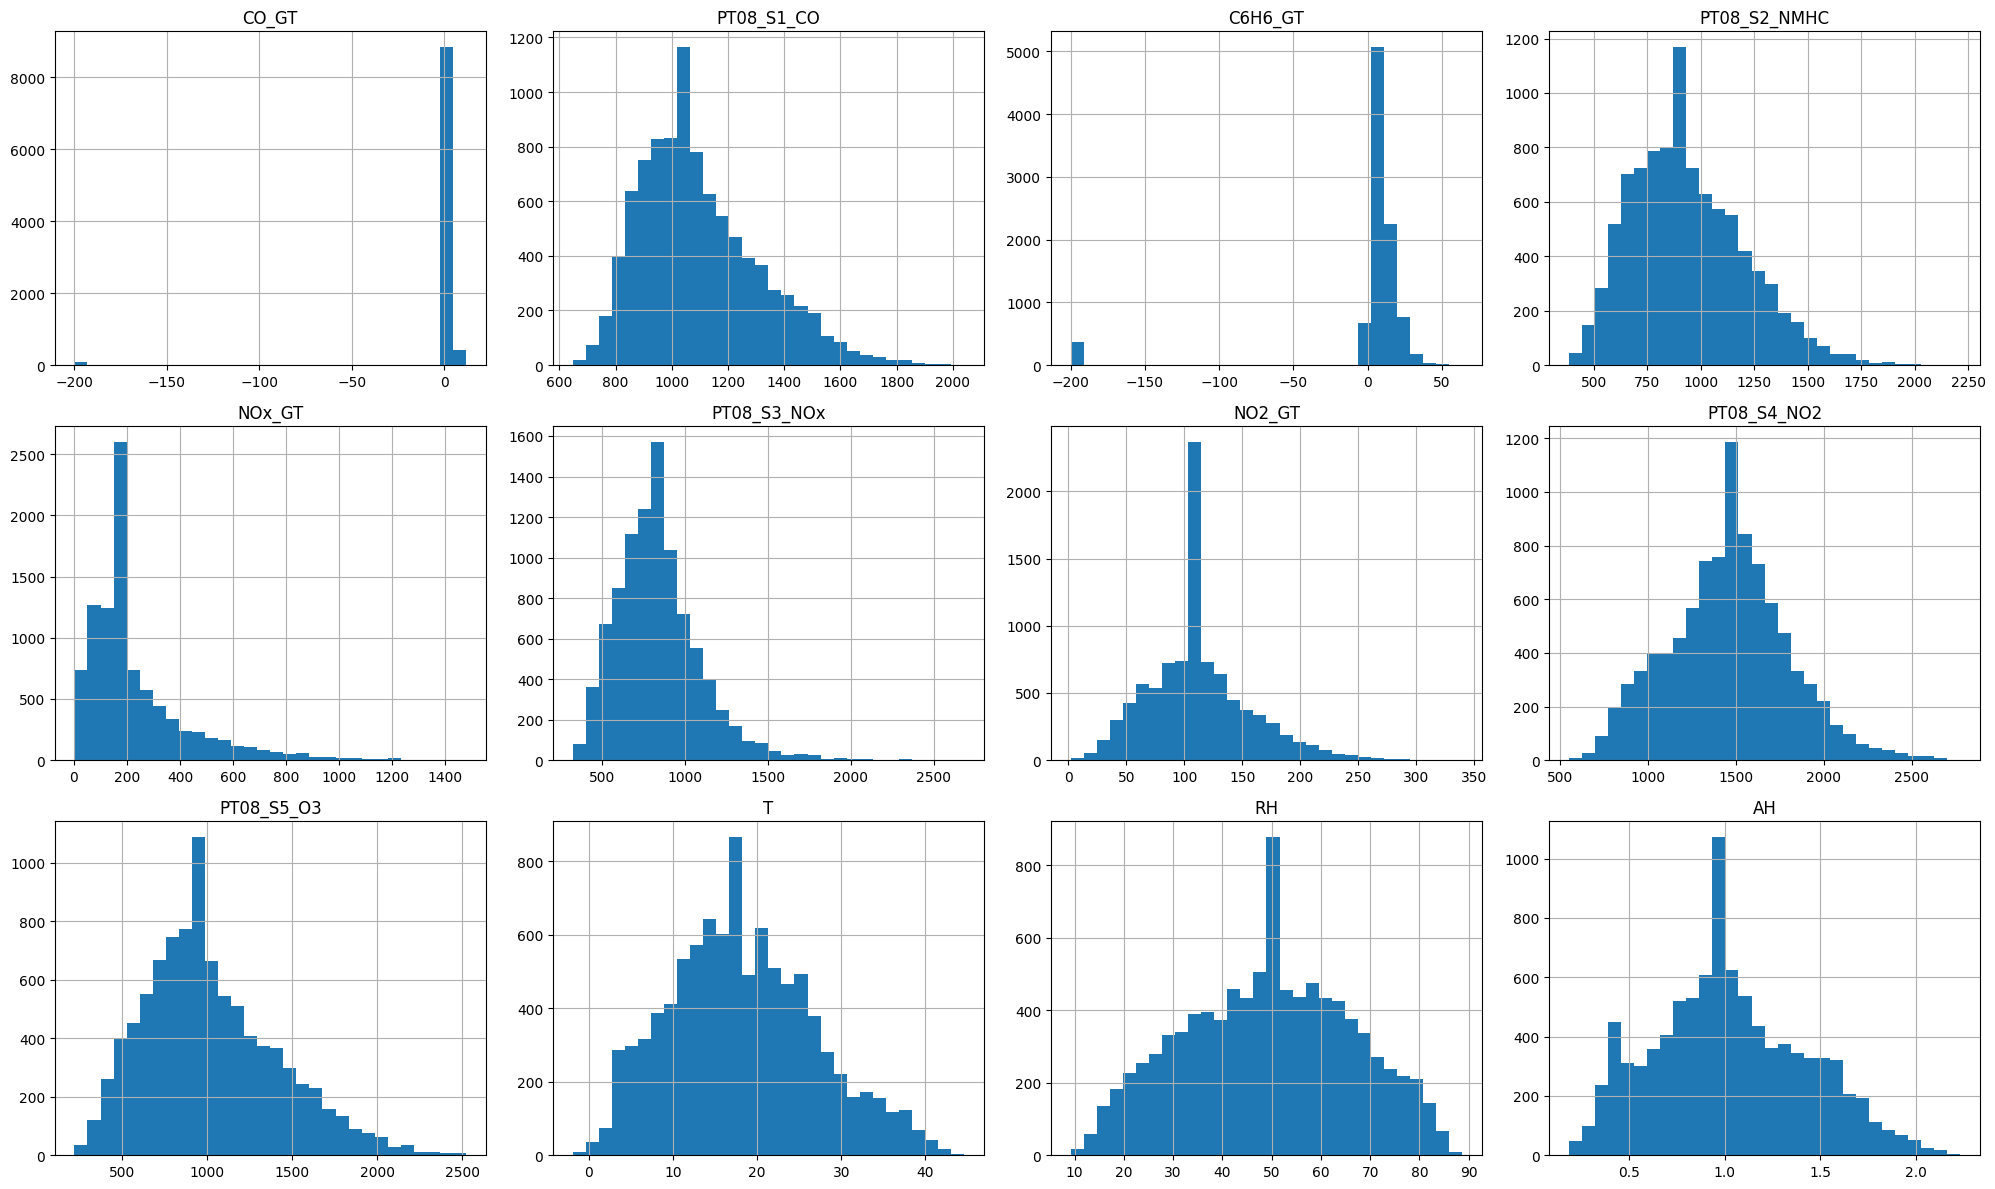

In [87]:
cols = [
    'CO_GT', 'PT08_S1_CO', 'C6H6_GT', 'PT08_S2_NMHC',
    'NOx_GT', 'PT08_S3_NOx', 'NO2_GT', 'PT08_S4_NO2',
    'PT08_S5_O3', 'T', 'RH', 'AH'
]

air_quality[cols].hist(figsize=(20, 12), bins=30, layout=(3, 4))
plt.tight_layout()
plt.show()

## Data Cleaning

The dataset uses −200 as a sentinel value for missing data. We replace these with `NaN` so they don't skew the analysis.

In [88]:
## looks like they put - 200 for nan, such a weird outlier value, but we can replace it with np.nan

air_quality['Date'] = pd.to_datetime(air_quality['Date'])
air_quality = air_quality.replace(-200, np.nan)
air_quality.isna().sum()

Date              0
CO_GT            91
PT08_S1_CO        0
C6H6_GT         366
PT08_S2_NMHC      0
NOx_GT            0
PT08_S3_NOx       0
NO2_GT            0
PT08_S4_NO2       0
PT08_S5_O3        0
T                 0
RH                0
AH                0
Hour              0
high_NO2          0
dtype: int64

## Time-Based Trends

How do pollution levels change across hours of the day and across dates?

### Hourly Averages

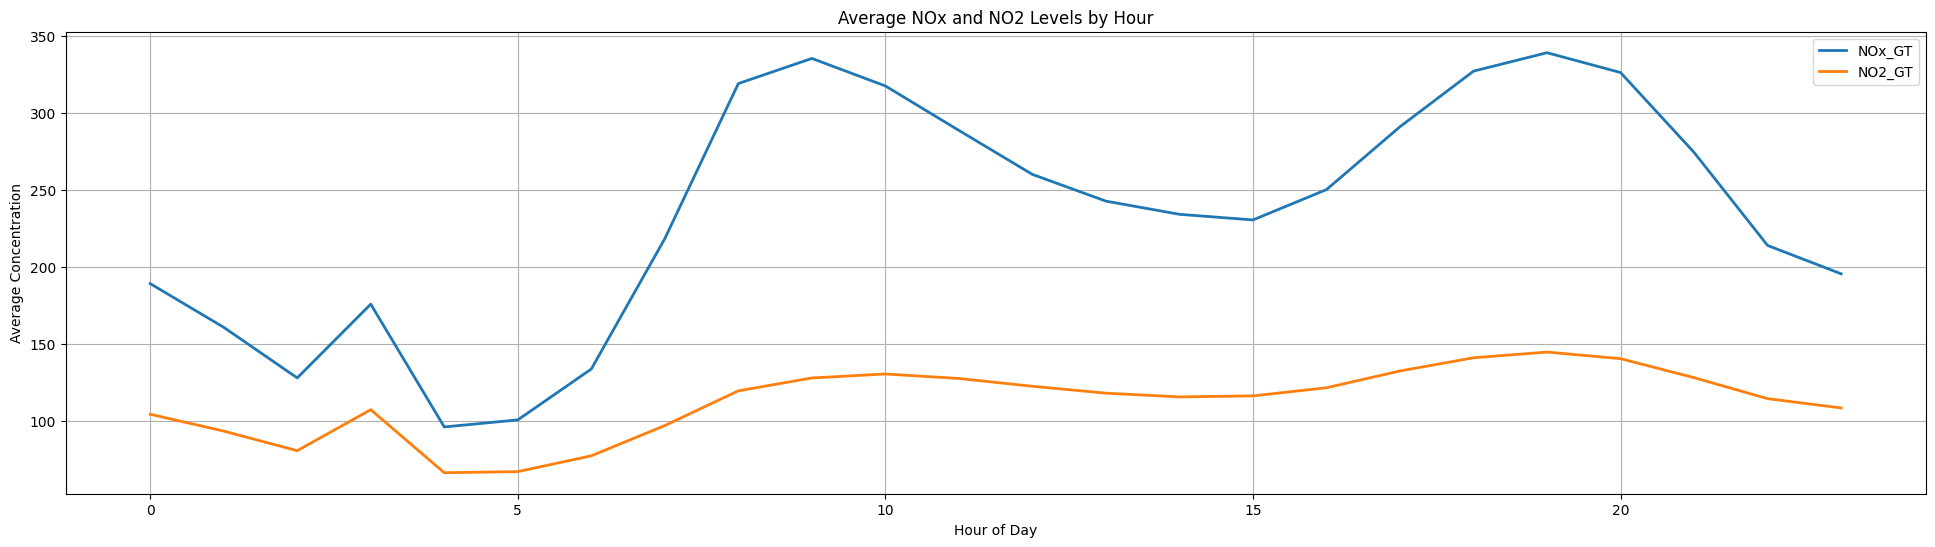

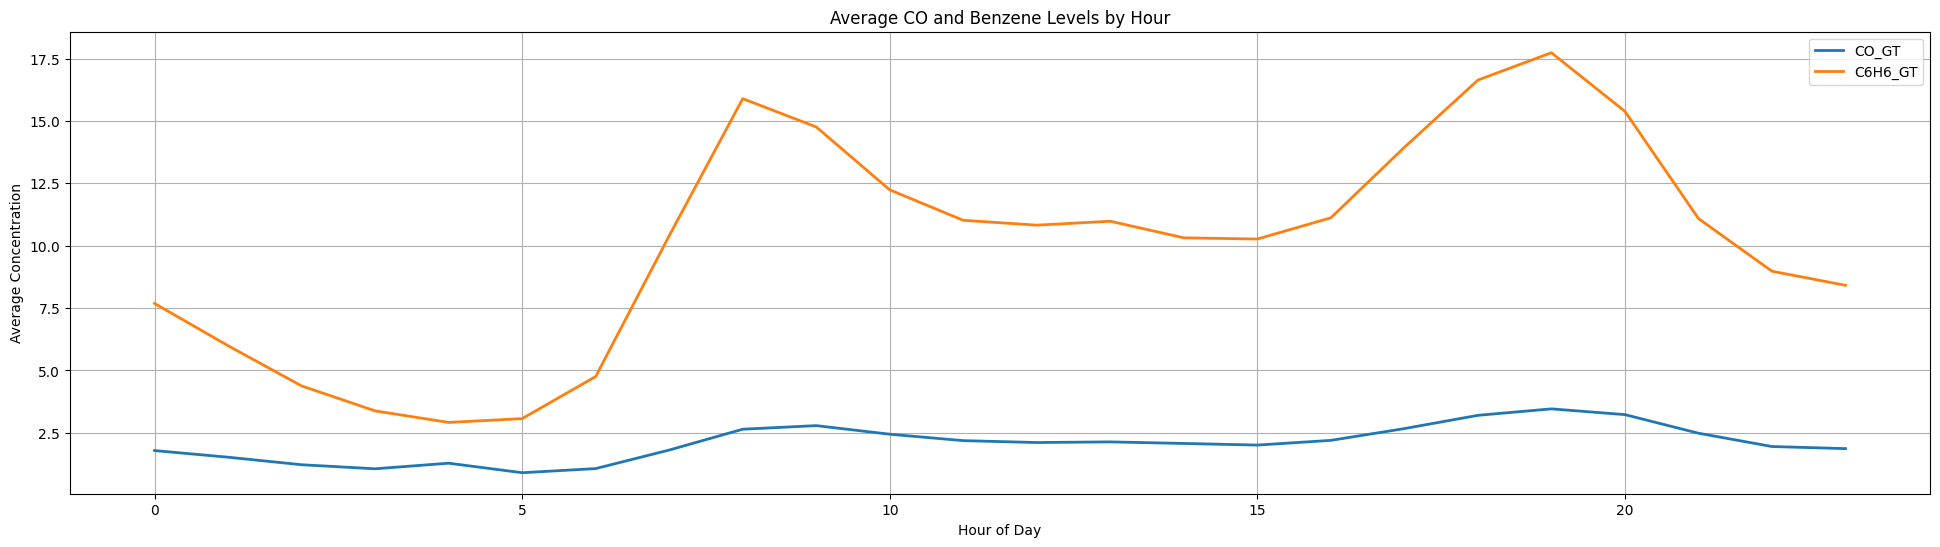

In [89]:
cols = ['CO_GT', 'C6H6_GT', 'NOx_GT', 'NO2_GT']

hourly_avg = air_quality.groupby('Hour')[cols].mean()

hourly_avg[['NOx_GT', 'NO2_GT']].plot(figsize=(24, 6), linewidth=2)
plt.xlabel("Hour of Day")
plt.ylabel("Average Concentration")
plt.title("Average NOx and NO2 Levels by Hour")
plt.grid(True)
plt.show()

hourly_avg[['CO_GT', 'C6H6_GT']].plot(figsize=(24, 6), linewidth=2)
plt.xlabel("Hour of Day")
plt.ylabel("Average Concentration")
plt.title("Average CO and Benzene Levels by Hour")
plt.grid(True)
plt.show()
plt.show()

### Daily Averages

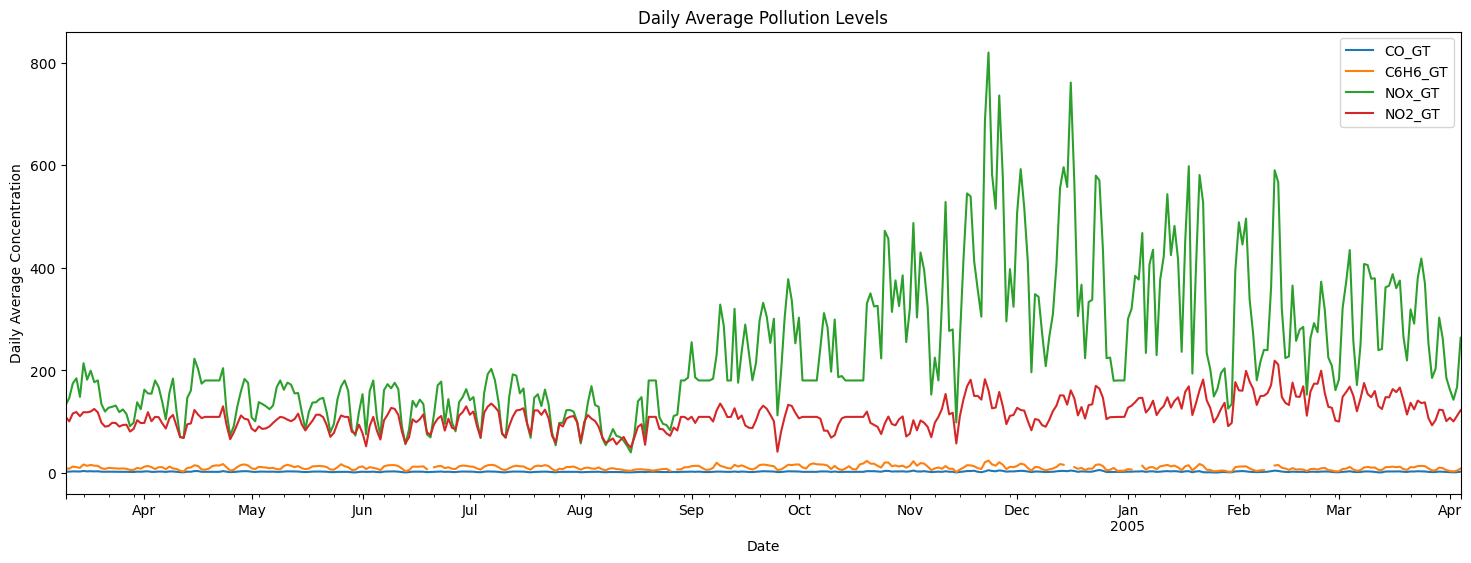

In [90]:
daily_avg = air_quality.groupby('Date')[['CO_GT', 'C6H6_GT', 'NOx_GT', 'NO2_GT']].mean()
daily_avg.plot(figsize=(18, 6))
plt.xlabel("Date")
plt.ylabel("Daily Average Concentration")
plt.title("Daily Average Pollution Levels")
plt.show()

## Correlation Matrix

Pairwise correlations across all numeric features (excluding `Hour`).

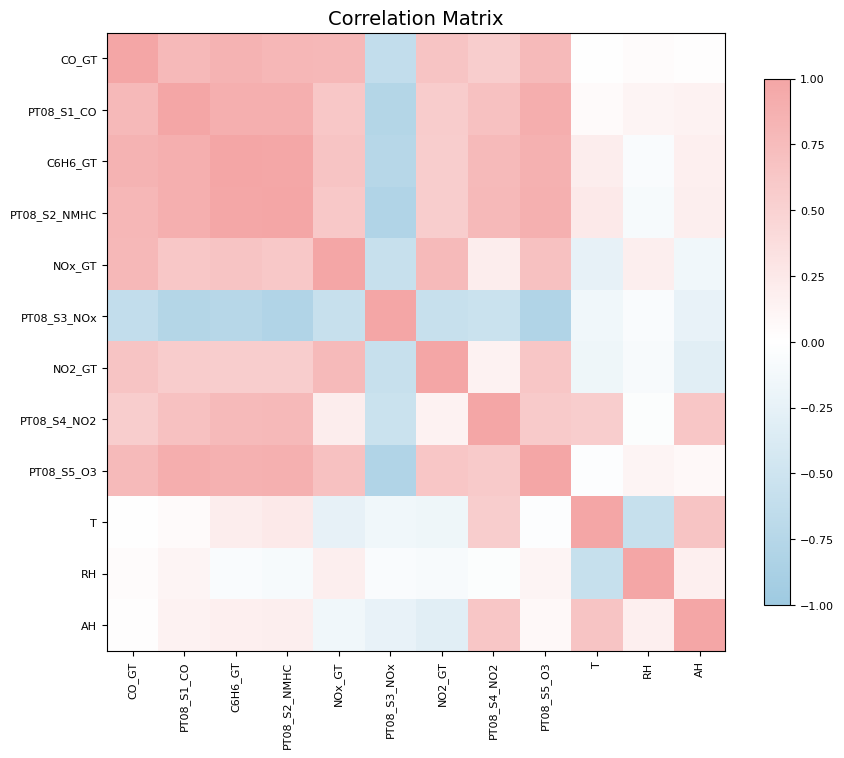

In [91]:
# optional: remove Hour if you don't want it in the correlation matrix
numeric_cols = [col for col in air_quality.columns if air_quality[col].dtype in [np.float64, np.int64]]
numeric_cols = [col for col in numeric_cols if col != 'Hour']
corr = air_quality[numeric_cols].corr()

cmap = LinearSegmentedColormap.from_list(
    "light_blue_red",
    ["#9ecae1", "white", "#f4a6a6"]
)

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)

cbar = fig.colorbar(im, ax=ax, shrink=0.75)
cbar.ax.tick_params(labelsize=8)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

ax.set_title("Correlation Matrix", fontsize=14)

plt.tight_layout()
plt.show()

## Sensor vs Ground-Truth Comparison

The figure below shows the relationship between sensor readings and ground-truth pollutant measurements for four gases. To reduce noise and overplotting, the sensor readings were grouped into bins, and the average ground-truth value was calculated within each bin. This makes it easier to see the general trend between each sensor and its corresponding pollutant measurement.

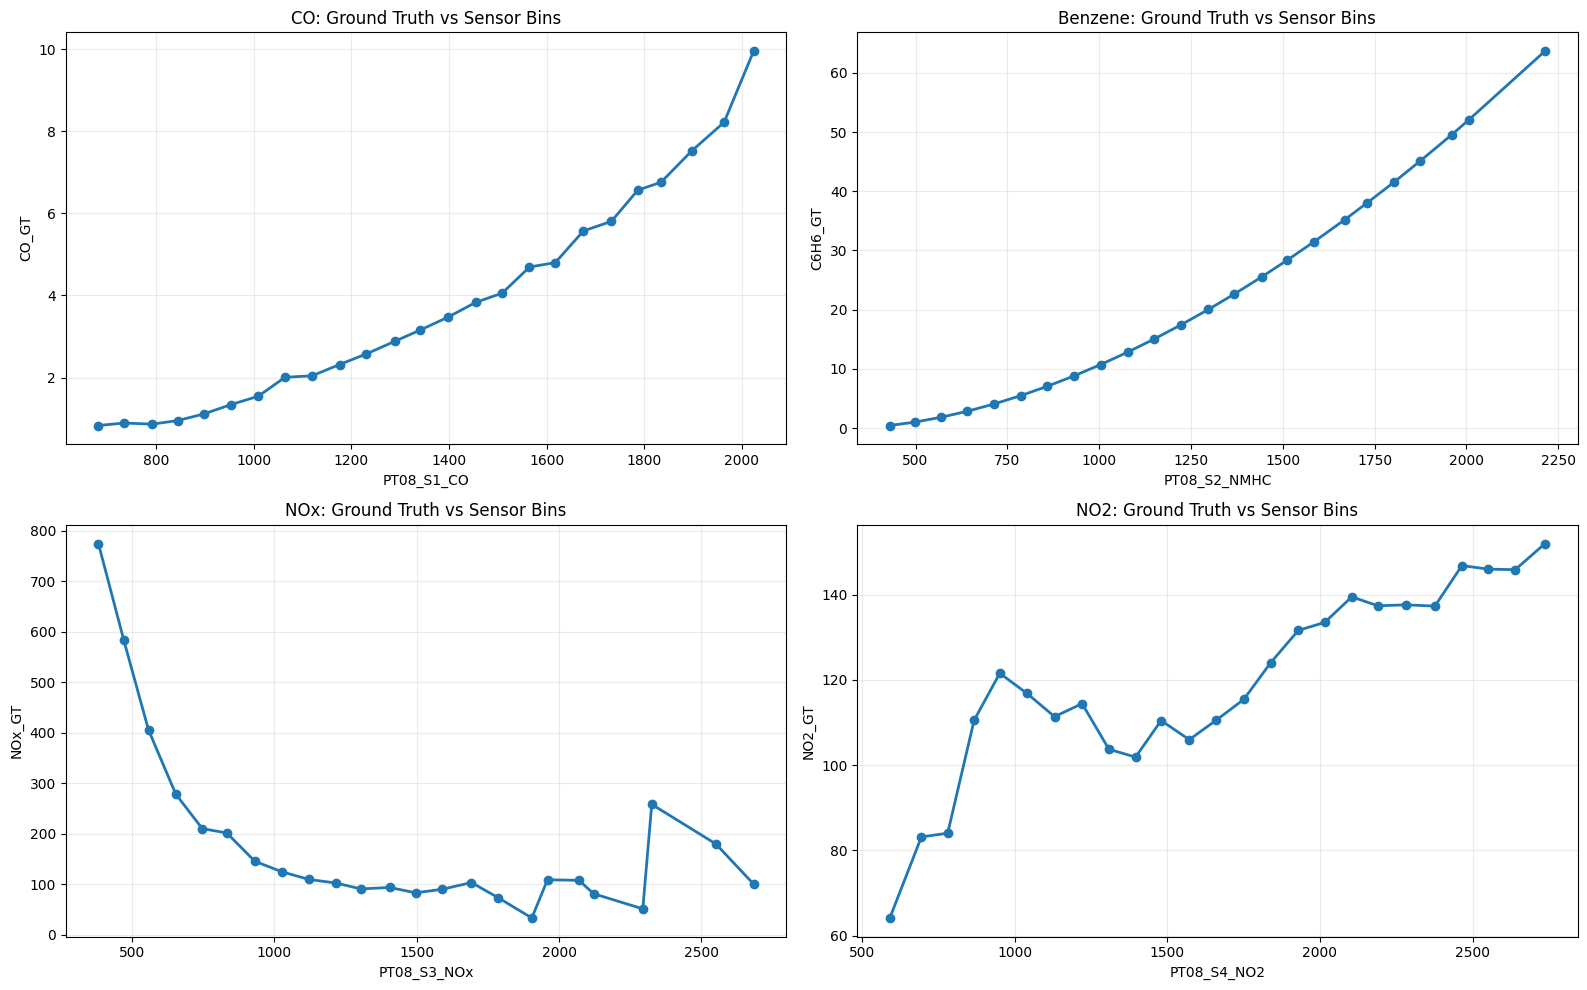

In [92]:
pairs = [
    ('PT08_S1_CO',   'CO_GT',   'CO'),
    ('PT08_S2_NMHC', 'C6H6_GT', 'Benzene'),
    ('PT08_S3_NOx',  'NOx_GT',  'NOx'),
    ('PT08_S4_NO2',  'NO2_GT',  'NO2')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i in range(len(pairs)):
    sensor_col, target_col, gas_name = pairs[i]
    
    plot_data = air_quality[[sensor_col, target_col]].dropna().copy()
    plot_data['sensor_bin'] = pd.cut(plot_data[sensor_col], bins=25)
    
    binned = plot_data.groupby('sensor_bin', observed=True).agg(
        avg_sensor=(sensor_col, 'mean'),
        avg_target=(target_col, 'mean')
    )
    
    axes[i].plot(binned['avg_sensor'], binned['avg_target'], marker='o', linewidth=2)
    axes[i].set_title(f'{gas_name}: Ground Truth vs Sensor Bins', fontsize=12)
    axes[i].set_xlabel(sensor_col, fontsize=10)
    axes[i].set_ylabel(target_col, fontsize=10)
    axes[i].grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

Because the sensor readings and ground-truth pollutant concentrations are measured on different scales, the ideal relationship is not a 1:1 diagonal line. Instead, we look for a clear monotonic pattern showing that higher sensor readings are consistently associated with higher or lower ground-truth pollutant levels. A smooth increasing or decreasing trend suggests that the sensor contains useful information about the actual pollutant concentration.